## Trabajo 2 — Técnicas avanzadas de IA

**Estudiante:** Emanuel Acevedo Muñoz

### Objetivo
Construir un modelo de clasificación de letras en **lenguaje de señas** (dataset **Sign Language MNIST**) y usar un **algoritmo basado en población** (algoritmo genético) para buscar una buena **arquitectura e hiperparámetros** de una red convolucional. La **función de aptitud (fitness)** es el **accuracy** en un conjunto de validación; en cada generación la población evoluciona para **maximizar** esa métrica.

### Referencias del curso
- Carga de datos: *Base sistema MNIST de signos de letras.ipynb* (CSV de Kaggle).
- Estilo de entrenamiento / hiperparámetros: *Ejemplo base para poder correr hiperparámetros.ipynb* (PyTorch, validación cruzada u objetivo externo). Aquí sustituimos la optimización bayesiana por un **AG** sobre el espacio de arquitecturas.

### 1. Dependencias

In [ ]:
%pip install -q kagglehub torch torchvision

In [ ]:
import os
import random
import copy
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.fx
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### 2. Carga del dataset Sign Language MNIST
Misma fuente que en el notebook base: [sign-language-mnist](https://www.kaggle.com/datasets/datamunge/sign-language-mnist) (`sign_mnist_train.csv`, `sign_mnist_test.csv`).

In [ ]:
def resolve_data_dir() -> str:
    """Colab: kagglehub. Local: carpeta del proyecto o variable de entorno SIGN_MNIST_DIR."""
    env = os.environ.get("SIGN_MNIST_DIR")
    if env and os.path.isdir(env):
        return env
    try:
        import kagglehub
        path = kagglehub.dataset_download("datamunge/sign-language-mnist")
        return path
    except Exception:
        return os.getcwd()


def find_csv(base: str, name: str) -> str:
    for root, _, files in os.walk(base):
        if name in files:
            return os.path.join(root, name)
    raise FileNotFoundError(f"No se encontró {name} bajo {base}")


DATA_ROOT = resolve_data_dir()
print("DATA_ROOT:", DATA_ROOT)

train_path = find_csv(DATA_ROOT, "sign_mnist_train.csv")
test_path = find_csv(DATA_ROOT, "sign_mnist_test.csv")
print("train:", train_path)
print("test:", test_path)

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_train.head()

Using Colab cache for faster access to the 'sign-language-mnist' dataset.
DATA_ROOT: /kaggle/input/sign-language-mnist
train: /kaggle/input/sign-language-mnist/sign_mnist_train.csv
test: /kaggle/input/sign-language-mnist/sign_mnist_test.csv


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [ ]:
X_all = df_train.drop(columns=["label"]).values.astype(np.float32) / 255.0
y_all = df_train["label"].values.astype(np.int64)
X_test = df_test.drop(columns=["label"]).values.astype(np.float32) / 255.0
y_test = df_test["label"].values.astype(np.int64)

num_classes = int(np.max(y_all)) + 1
print("Número de clases (etiquetas 0..N-1):", num_classes)
print("Train:", X_all.shape, "Test:", X_test.shape)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=0.15, random_state=SEED, stratify=y_all
)

Número de clases (etiquetas 0..N-1): 25
Train: (27455, 784) Test: (7172, 784)


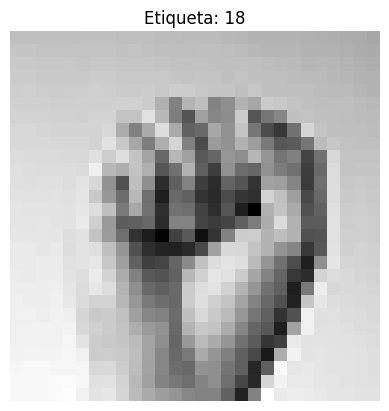

In [ ]:
class SignMNISTDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).view(-1, 1, 28, 28)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


ds_train = SignMNISTDataset(X_tr, y_tr)
ds_val = SignMNISTDataset(X_val, y_val)
ds_test = SignMNISTDataset(X_test, y_test)

idx = np.random.randint(len(ds_train))
img, lab = ds_train[idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Etiqueta: {lab.item()}")
plt.axis("off")
plt.show()

### 3. Codificación del individuo (arquitectura + hiperparámetros)
Cada individuo es un vector entero de genes; se mapea a una CNN con dos bloques convolucionales + capa densa. Los genes controlan filtros, tamaño de capa densa, dropout y tasa de aprendizaje.

In [ ]:
@dataclass
class Genome:
    """Genes discretos; cada uno indexa una tabla de valores."""
    g_conv1: int   # 0..len(CONV1)-1
    g_conv2: int
    g_dense: int
    g_drop: int
    g_lr: int

    def as_tuple(self) -> Tuple[int, ...]:
        return (self.g_conv1, self.g_conv2, self.g_dense, self.g_drop, self.g_lr)


CONV1_OPTS = [16, 32, 64]
CONV2_OPTS = [32, 64, 128, 256]
DENSE_OPTS = [64, 128, 256, 512]
DROP_OPTS = [0.0, 0.25, 0.4, 0.5]
LR_OPTS = [1e-4, 5e-4, 1e-3, 3e-3]

GENE_BOUNDS = [
    (0, len(CONV1_OPTS) - 1),
    (0, len(CONV2_OPTS) - 1),
    (0, len(DENSE_OPTS) - 1),
    (0, len(DROP_OPTS) - 1),
    (0, len(LR_OPTS) - 1),
]


def random_genome(rng: random.Random) -> Genome:
    return Genome(
        g_conv1=rng.randint(*GENE_BOUNDS[0]),
        g_conv2=rng.randint(*GENE_BOUNDS[1]),
        g_dense=rng.randint(*GENE_BOUNDS[2]),
        g_drop=rng.randint(*GENE_BOUNDS[3]),
        g_lr=rng.randint(*GENE_BOUNDS[4]),
    )


def genome_to_hparams(g: Genome):
    return {
        "c1": CONV1_OPTS[g.g_conv1],
        "c2": CONV2_OPTS[g.g_conv2],
        "hidden": DENSE_OPTS[g.g_dense],
        "dropout": DROP_OPTS[g.g_drop],
        "lr": LR_OPTS[g.g_lr],
    }


class ConvClassifier(nn.Module):
    def __init__(self, num_classes: int, c1: int, c2: int, hidden: int, dropout: float):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, c1, kernel_size=3, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c2 * 7 * 7, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)


def build_model(g: Genome, num_classes: int) -> ConvClassifier:
    h = genome_to_hparams(g)
    return ConvClassifier(
        num_classes=num_classes,
        c1=h["c1"],
        c2=h["c2"],
        hidden=h["hidden"],
        dropout=h["dropout"],
    ).to(device)

### 4. Entrenamiento y fitness (accuracy de validación)
Para la fase evolutiva usamos pocas épocas por individuo para que el AG sea viable; al final se reentrena el mejor individuo con más épocas.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * xb.size(0)
        total += xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss_sum += loss.item() * xb.size(0)
        total += xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
    return loss_sum / total, correct / total


def fitness_of_genome(
    g: Genome,
    num_classes: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
) -> float:
    """Devuelve accuracy en validación (maximizar)."""
    model = build_model(g, num_classes)
    h = genome_to_hparams(g)
    opt = torch.optim.Adam(model.parameters(), lr=h["lr"])
    crit = nn.CrossEntropyLoss()
    best_acc = 0.0
    for _ in range(epochs):
        train_one_epoch(model, train_loader, opt, crit)
        _, acc_val = evaluate(model, val_loader, crit)
        best_acc = max(best_acc, acc_val)
    return best_acc

### 5. Algoritmo genético (población + generaciones)
- **Población:** conjunto de genomas (arquitecturas).
- **Selección:** torneo.
- **Cruce:** un punto sobre el vector de genes.
- **Mutación:** perturbación aleatoria de un gen con probabilidad `p_mut`.
- **Elitismo:** el mejor individuo pasa a la siguiente generación sin cruzar.

Ajuste `POP_SIZE`, `N_GENERATIONS`, `EPOCHS_GA` y tamaño de batch según RAM/GPU (en Colab suele ir bien lo propuesto).

In [ ]:
def tournament_select(pop: List[Genome], fitness: List[float], k: int, rng: random.Random) -> Genome:
    contenders = rng.sample(range(len(pop)), k=k)
    best = max(contenders, key=lambda i: fitness[i])
    return copy.deepcopy(pop[best])


def crossover(a: Genome, b: Genome, rng: random.Random) -> Tuple[Genome, Genome]:
    genes_a = list(a.as_tuple())
    genes_b = list(b.as_tuple())
    point = rng.randint(1, len(genes_a) - 1)
    genes_a[point:], genes_b[point:] = genes_b[point:], genes_a[point:]
    return Genome(*genes_a), Genome(*genes_b)


def mutate(g: Genome, p_mut: float, rng: random.Random) -> Genome:
    genes = list(g.as_tuple())
    for i in range(len(genes)):
        if rng.random() < p_mut:
            lo, hi = GENE_BOUNDS[i]
            genes[i] = rng.randint(lo, hi)
    return Genome(*genes)


def run_genetic_algorithm(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_classes: int,
    pop_size: int = 10,
    n_generations: int = 6,
    epochs_per_eval: int = 4,
    crossover_rate: float = 0.85,
    mutation_rate: float = 0.25,
    tournament_k: int = 3,
    seed: int = SEED,
) -> Tuple[Genome, List[float], List[float]]:
    rng = random.Random(seed)
    population = [random_genome(rng) for _ in range(pop_size)]
    best_ever: Genome = copy.deepcopy(population[0])
    best_ever_fit = -1.0
    history_best: List[float] = []
    history_mean: List[float] = []

    for gen in range(n_generations):
        fitness: List[float] = []
        for ind in population:
            fit = fitness_of_genome(
                ind, num_classes, train_loader, val_loader, epochs=epochs_per_eval
            )
            fitness.append(fit)
            if fit > best_ever_fit:
                best_ever_fit = fit
                best_ever = copy.deepcopy(ind)

        history_best.append(max(fitness))
        history_mean.append(float(np.mean(fitness)))
        print(
            f"Gen {gen+1}/{n_generations} | "
            f"best esta gen: {max(fitness):.4f} | mean: {np.mean(fitness):.4f} | "
            f"best global: {best_ever_fit:.4f}"
        )

        next_pop: List[Genome] = []
        best_idx = int(np.argmax(fitness))
        next_pop.append(copy.deepcopy(population[best_idx]))

        while len(next_pop) < pop_size:
            parent1 = tournament_select(population, fitness, tournament_k, rng)
            parent2 = tournament_select(population, fitness, tournament_k, rng)
            if rng.random() < crossover_rate:
                child1, child2 = crossover(parent1, parent2, rng)
            else:
                child1, child2 = copy.deepcopy(parent1), copy.deepcopy(parent2)
            child1 = mutate(child1, mutation_rate, rng)
            child2 = mutate(child2, mutation_rate, rng)
            next_pop.append(child1)
            if len(next_pop) < pop_size:
                next_pop.append(child2)

        population = next_pop[:pop_size]

    return best_ever, history_best, history_mean

In [ ]:
BATCH_SIZE = 128
train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

POP_SIZE = 4
N_GENERATIONS = 3
EPOCHS_GA = 2

best_genome, hist_best, hist_mean = run_genetic_algorithm(
    train_loader,
    val_loader,
    num_classes=num_classes,
    pop_size=POP_SIZE,
    n_generations=N_GENERATIONS,
    epochs_per_eval=EPOCHS_GA,
)

print("\n=== Mejor genoma encontrado ===")
print("Genes:", best_genome)
print("Hiperparámetros:", genome_to_hparams(best_genome))

Gen 1/3 | best esta gen: 1.0000 | mean: 0.9944 | best global: 1.0000
Gen 2/3 | best esta gen: 0.9990 | mean: 0.9974 | best global: 1.0000
Gen 3/3 | best esta gen: 1.0000 | mean: 0.9754 | best global: 1.0000

=== Mejor genoma encontrado ===
Genes: Genome(g_conv1=0, g_conv2=1, g_dense=0, g_drop=0, g_lr=3)
Hiperparámetros: {'c1': 16, 'c2': 64, 'hidden': 64, 'dropout': 0.0, 'lr': 0.003}


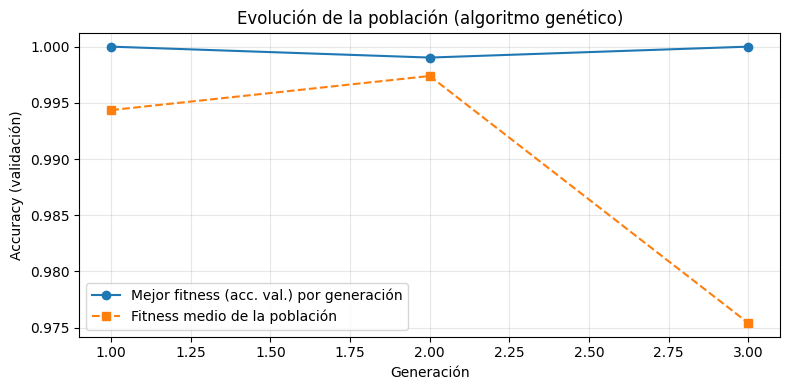

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(hist_best) + 1), hist_best, "o-", label="Mejor fitness (acc. val.) por generación")
plt.plot(range(1, len(hist_mean) + 1), hist_mean, "s--", label="Fitness medio de la población")
plt.xlabel("Generación")
plt.ylabel("Accuracy (validación)")
plt.title("Evolución de la población (algoritmo genético)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6. Reentrenamiento del mejor individuo (más épocas)
Se entrena de nuevo la arquitectura ganadora con más iteraciones y early stopping según validación.

In [ ]:
class EarlyStoppingAcc:
    def __init__(self, patience: int = 5, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.counter = 0
        self.best_state = None

    def step(self, acc: float, model: nn.Module) -> bool:
        if self.best is None or acc > self.best + self.min_delta:
            self.best = acc
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience


def train_final(g: Genome, epochs_max: int = 40, patience: int = 6):
    model = build_model(g, num_classes)
    h = genome_to_hparams(g)
    opt = torch.optim.Adam(model.parameters(), lr=h["lr"])
    crit = nn.CrossEntropyLoss()
    es = EarlyStoppingAcc(patience=patience)
    history = {"train_acc": [], "val_acc": []}
    for epoch in range(epochs_max):
        _, acc_tr = train_one_epoch(model, train_loader, opt, crit)
        _, acc_val = evaluate(model, val_loader, crit)
        history["train_acc"].append(acc_tr)
        history["val_acc"].append(acc_val)
        if es.step(acc_val, model):
            print(f"Early stopping en época {epoch+1}")
            break
    if es.best_state is not None:
        model.load_state_dict(es.best_state)
    return model, history


model_final, hist_final = train_final(best_genome, epochs_max=45, patience=8)
crit = nn.CrossEntropyLoss()
_, acc_val_final = evaluate(model_final, val_loader, crit)
test_loader = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
_, acc_test = evaluate(model_final, test_loader, crit)
print(f"Accuracy validación (mejor checkpoint): {acc_val_final:.4f}")
print(f"Accuracy test (holdout): {acc_test:.4f}")

Early stopping en época 11
Accuracy validación (mejor checkpoint): 1.0000
Accuracy test (holdout): 0.9212


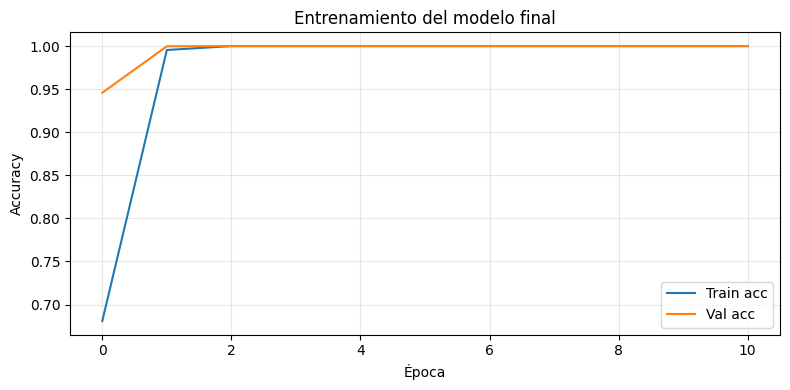

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(hist_final["train_acc"], label="Train acc")
plt.plot(hist_final["val_acc"], label="Val acc")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Entrenamiento del modelo final")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7. Pruebas visuales (test)
Hay **cuatro celdas de código**: en la primera se define `mostrar_prediccion` y se muestra un ejemplo; en las otras tres solo cambia el **índice** del conjunto de test. En cada una se ve la **imagen**, la etiqueta **real** (número y letra) y la **predicción** del `model_final` con **confianza** (softmax).

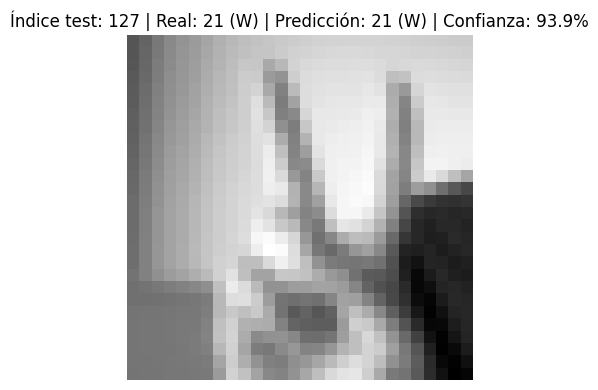

In [ ]:
# Sign MNIST: 25 letras (A–Z sin J ni Z), etiquetas 0..24
LETRAS_SIGN = "ABCDEFGHIKLMNOPQRSTUVWXY"


def etiqueta_a_letra(y: int) -> str:
    if 0 <= y < len(LETRAS_SIGN):
        return LETRAS_SIGN[y]
    return "?"


@torch.no_grad()
def mostrar_prediccion(indice_test: int):
    model_final.eval()
    x, y_true = ds_test[indice_test]
    xb = x.unsqueeze(0).to(device)
    logits = model_final(xb)
    probs = torch.softmax(logits, dim=1)
    conf, pred = probs.max(dim=1)
    y_pred = int(pred.item())
    yt = int(y_true.item())
    conf_f = float(conf.item())

    plt.figure(figsize=(8, 4))
    plt.imshow(x.squeeze().cpu().numpy(), cmap="gray")
    plt.title(
        f"Índice test: {indice_test} | "
        f"Real: {yt} ({etiqueta_a_letra(yt)}) | "
        f"Predicción: {y_pred} ({etiqueta_a_letra(y_pred)}) | "
        f"Confianza: {conf_f:.1%}"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


mostrar_prediccion(127)

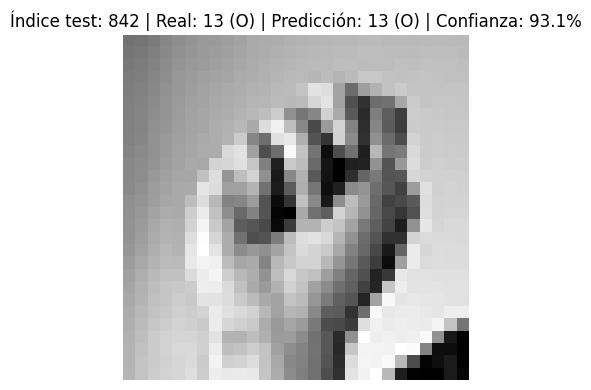

In [ ]:
mostrar_prediccion(842)

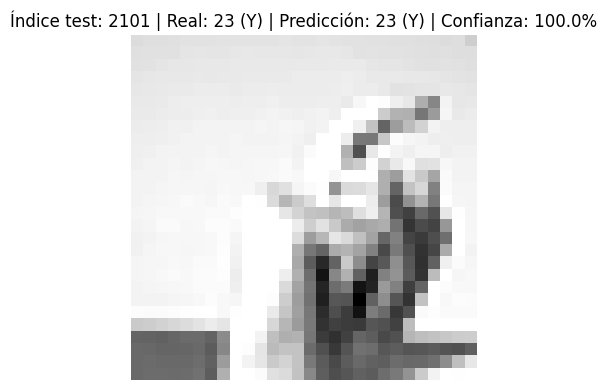

In [ ]:
mostrar_prediccion(2101)

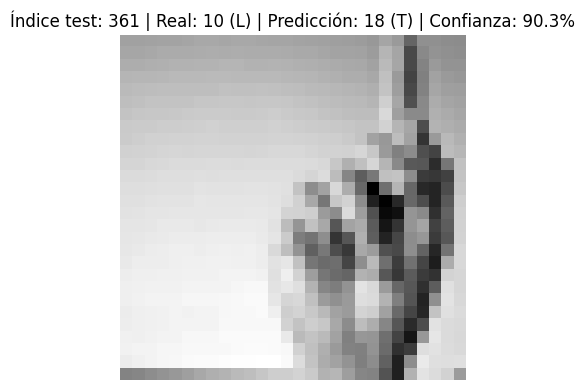

In [ ]:
mostrar_prediccion(361)

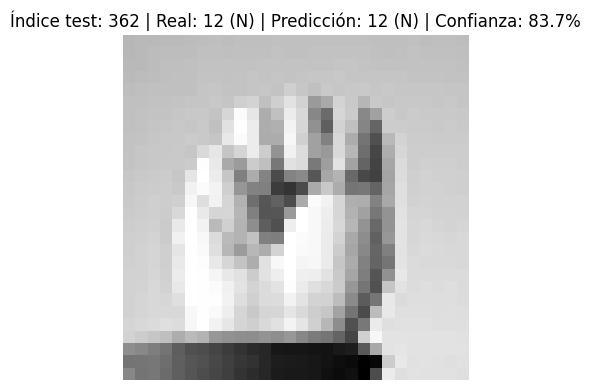

In [ ]:
mostrar_prediccion(362)

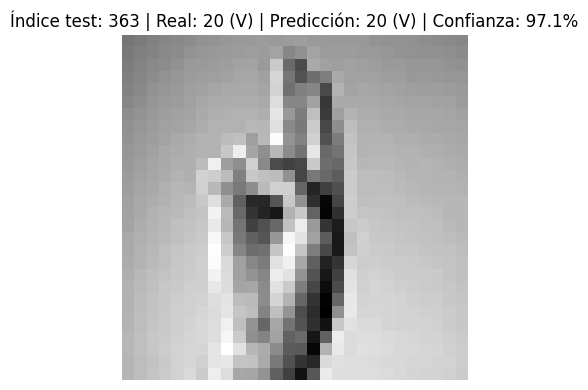

In [ ]:
mostrar_prediccion(363)

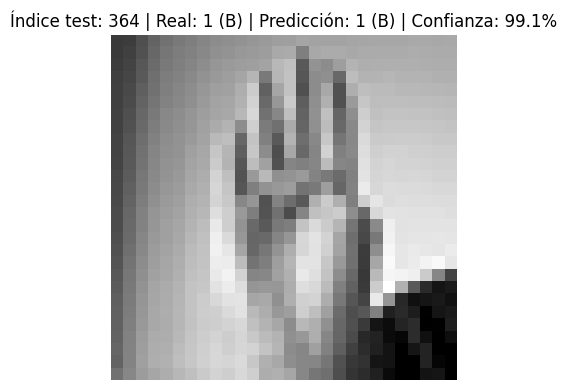

In [ ]:
mostrar_prediccion(364)

### 8. Conclusiones
- Se implementó un **algoritmo genético** sobre una población de arquitecturas CNN; la métrica optimizada fue el **accuracy en validación**.
- En cada generación se observa la **mejora (en tendencia) del mejor individuo y de la media**, sujeta al ruido del entrenamiento corto por individuo.
- Para la entrega en Colab, puede **aumentar** `POP_SIZE`, `N_GENERATIONS` y `EPOCHS_GA` si el tiempo de ejecución lo permite.


1. **Contexto y objetivo**  
   Clasificación de letras con **Sign Language MNIST**, alineado con tu *Base sistema MNIST de signos de letras* y con la idea del *Ejemplo base…* (PyTorch + búsqueda de hiperparámetros), pero usando **algoritmo de población** en lugar de bayesiano.

2. **Datos**  
   - Descarga con **`kagglehub`** (`datamunge/sign-language-mnist`) como en Colab.  
   - Si no hay red o falla: **`SIGN_MNIST_DIR`** apuntando a la carpeta con los CSV, o **`os.getcwd()`** si los CSV están bajo el directorio actual.  
   - Normalización a \([0,1]\), split train/val estratificado.

3. **Modelo**  
   CNN con 2 bloques conv + BN + ReLU + MaxPool, capa densa y dropout; **genes** que fijan filtros conv1/conv2, neuronas ocultas, dropout y **learning rate**.

4. **Algoritmo de población**  
   **Algoritmo genético**: torneo, cruce en un punto, mutación, elitismo. **Fitness = accuracy en validación** (maximizar). En cada generación se imprime el mejor de la generación, la media y el mejor global hasta el momento.

5. **Gráficas**  
   - Evolución del mejor fitness y de la media por generación.  
   - Curvas train/val del **reentrenamiento** del mejor individuo.

6. **Reentrenamiento final**  
   Más épocas + **early stopping** con el mejor checkpoint según validación; evaluación en **test** (`sign_mnist_test.csv`).

Parámetros pensados para ejecutar en Colab sin explotar el tiempo: `POP_SIZE = 8`, `N_GENERATIONS = 5`, `EPOCHS_GA = 4` por evaluación en el AG. Puedes subirlos en la celda correspondiente para un informe más fuerte.